# Якість даних

`bigquery-public-data.google_analytics_sample`, серпень 2016 — серпень 2017
Числа рахуються запитами з `sql/00_data_quality.sql`, результати вивантажені в `data/`.

Перед аналізом треба знати, що в даних лежить насправді і де вони поводяться не так, як здається з назв полів. Кожна перевірка тут закінчується рішенням — від них залежать усі подальші розрахунки, і ухвалити їх треба до першого тесту, поки ще не видно, який варіант дає красивішу картинку. Рішення, що впливають на перевірку гіпотез, переносяться в `hypotheses.md`.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('data') if Path('data').exists() else Path('..') / 'data'
if not DATA.exists():
    raise FileNotFoundError(f'Не знайдено теку з даними: {DATA.resolve()}')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def load(name):
    return pd.read_csv(DATA / name)

plt.rcParams.update({
    'figure.figsize': (9, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

## Обсяг даних

In [29]:
dup = load('02_session_duplicates.csv')
ch  = load('01_unknown_channels.csv')

rows      = int(dup.rows_total[0])
sessions  = int(dup.distinct_sessions[0])
visitors  = int(dup.distinct_visitors[0])

print(f'Рядків у таблицях:        {rows:,}')
print(f'Унікальних сесій:         {sessions:,}')
print(f'Унікальних відвідувачів:  {visitors:,}')
print(f'Сесій на відвідувача:     {sessions / visitors:.2f}')

Рядків у таблицях:        903,653
Унікальних сесій:         902,755
Унікальних відвідувачів:  714,167
Сесій на відвідувача:     1.26


Масштаб робочий: майже мільйон сесій за 12 місяців, покупок серед них близько 1,3%. Рішення взяти весь період, а не один місяць, було правильним. Далі дані доведеться ділити одночасно за каналом і за кроком воронки — це кілька десятків груп. За рік покупок 11,5 тисяч, за місяць було б близько тисячі, і в кожній групі лишилося б по кілька десятків спостережень: надто мало для будь-якого тесту.

Сесій на відвідувача — 1,27. Більшість людей приходить один раз і не повертається. Це знадобиться в кінці, коли йтиметься про гіпотезу 4.

## 1. Джерела трафіку

In [30]:
display(ch)

pct_unknown = 100 * ch.unknown_channel[0] / sessions
pct_direct  = 100 * ch.source_direct[0]   / sessions

print(f'Без визначеного каналу: {ch.unknown_channel[0]:,} сесій ({pct_unknown:.3f}%)')
print(f'Direct:                 {ch.source_direct[0]:,} сесій ({pct_direct:.1f}%)')

,sessions,unknown_channel,medium_none_or_notset,source_direct,pct_unknown_channel
0,903653,120,371584,371469,0.01


Без визначеного каналу: 120 сесій (0.013%)
Direct:                 371,469 сесій (41.1%)


Сесій без визначеного каналу виявилося 120, тобто 0,013%. Я очікувала, що доведеться виключати помітну частку даних, а виключати практично нічого — ці 120 сесій прибираю з міжканальних порівнянь, вони не змінять жодного числа.

Натомість спливло інше, чого я не шукала: direct — це 41% усього трафіку, найбільша група в датасеті. Залишаю його як повноцінний канал. Це валідна категорія: прямі заходи, збережені закладки і все, для чого браузер не передав реферер.

Але саме через розмір direct і є головним бенефіціаром атрибуції за останнім кліком. Людина, яка вперше прийшла з пошуку, а купила з закладки, віддає всю заслугу direct. Це те, що перевіряє гіпотеза 4, і тепер видно, що ставки там високі — йдеться про 41% трафіку, а не про маргінальну групу.

## 2. Чи справді один рядок = одна сесія

In [31]:
dup_keys = rows - sessions
print(f'Рядків:                    {rows:,}')
print(f'Унікальних ключів сесії:   {sessions:,}')
print(f'Різниця (дублі ключа):     {dup_keys:,} ({100 * dup_keys / rows:.3f}%)')

Рядків:                    903,653
Унікальних ключів сесії:   902,755
Різниця (дублі ключа):     898 (0.099%)


Ключ `fullVisitorId + visitId` виявився не унікальним: 898 рядків мають дубль ключа, 0,099% даних. Причина технічна — `visitId` це час початку візиту в unix-форматі, і він повторюється, коли сесія перетинає межу доби й потрапляє у дві денні таблиці. Додаю до ключа дату: `fullVisitorId + visitId + date`. Так він стає унікальним, і жоден рядок не втрачається.

Ці 0,1% не змінять жодного висновку. Фіксую їх, щоб `COUNT(*)` і `COUNT(DISTINCT ключ)` не розходилися в різних запитах — інакше через тиждень я не згадаю, яке з двох чисел правильне.

## 3. Послідовність воронки — головна знахідка блоку

In [32]:
fs = load('03_funnel_steps.csv')
display(fs)

p  = int(fs.purchase_sessions[0])
nv = int(fs.purchase_without_view[0])
nc = int(fs.purchase_without_cart[0])
nk = int(fs.purchase_without_checkout[0])

for label, n in [('без перегляду товару', nv), ('без додавання в кошик', nc), ('без checkout', nk)]:
    print(f'Покупок {label:<24} {n:>6,}  ({100 * n / p:5.2f}%)')

,purchase_sessions,purchase_without_view,purchase_without_cart,purchase_without_checkout,pct_purchase_without_view
0,11551,2163,1421,7,18.73


Покупок без перегляду товару      2,163  (18.73%)
Покупок без додавання в кошик     1,421  (12.30%)
Покупок без checkout                  7  ( 0.06%)


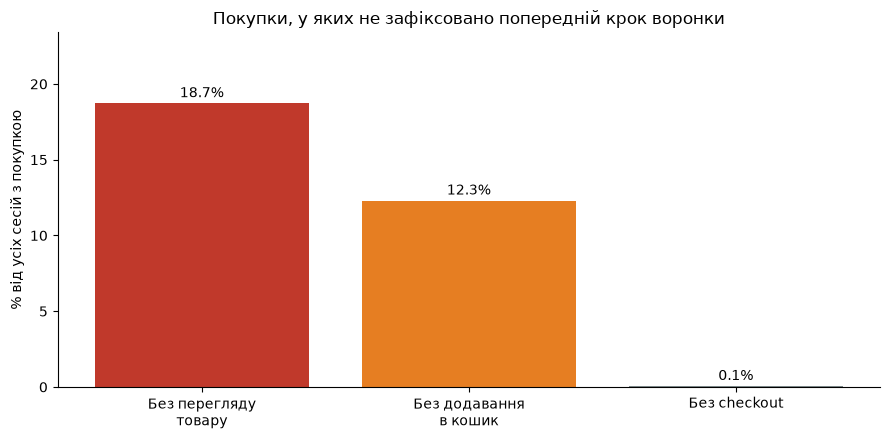

In [33]:
labels = ['Без перегляду\nтовару', 'Без додавання\nв кошик', 'Без checkout']
vals   = [100 * nv / p, 100 * nc / p, 100 * nk / p]

fig, ax = plt.subplots()
bars = ax.bar(labels, vals, color=['#c0392b', '#e67e22', '#7f8c8d'])
ax.set_ylabel('% від усіх сесій з покупкою')
ax.set_title('Покупки, у яких не зафіксовано попередній крок воронки')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.4, f'{v:.1f}%', ha='center')
ax.set_ylim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()

У 18,7% сесій з покупкою немає зафіксованого перегляду картки товару, у 12,3% — немає додавання в кошик. А без checkout — лише 7 покупок з 11 551, тобто 0,06%.

Цікавий тут радше розподіл пропусків, ніж їхній обсяг: низ воронки цілісний, верх — ні. Якби дані були биті випадково, пропуски розподілилися б рівномірно по кроках.

Тому будую воронку монотонною: якщо сесія досягла кроку k, вона зараховується як така, що пройшла всі попередні, незалежно від того, чи зафіксована відповідна подія. Строгу версію рахую теж, як контроль, і розбіжність виношу в README.

Причин дві. Перша: `action_type = '2'` фіксується не при кожному способі потрапити до товару — з кошика, зі списку побажань чи за прямим посиланням можна дійти до покупки, не згенерувавши цю подію. Друга: сесійна воронка обрізає поведінку між візитами, тому людина могла покласти товар у кошик учора, а купити сьогодні, і сьогоднішня сесія виглядатиме як покупка нізвідки. Якщо лишити строгу версію, конверсія кроку «перегляд — кошик» механічно завищиться: зі знаменника випадуть саме ті сесії, які пройшли крок непоміченими.

Це єдине рішення тут, яке впливає на сам результат перевірки: гіпотези 1 і 2 обидві про конверсії кроків. Тому воно записується в `hypotheses.md` до першого тесту: інакше на етапі аналізу спокуса вибрати ту версію воронки, яка дає зручнішу картинку, була б цілком реальною.

## 4. Дублікати transactionId

In [34]:
tx  = load('04_tx_duplicates.csv')
txe = load('04b_tx_duplicates_examples.csv')

display(tx)
display(txe.head(8))

,distinct_transaction_ids,ids_in_multiple_hits,ids_in_multiple_sessions
0,11552,11548,0


,tx_id,hit_rows,sessions_per_tx,revenue_sum_if_naive
0,ORD201703041515,50,1,"2,058.09"
1,ORD201703041514,42,1,"1,616.33"
2,ORD201705312661,30,1,480.00
3,ORD201703022050,24,1,"1,352.63"
4,ORD201703041891,20,1,"1,241.57"
5,ORD201703142587,16,1,936.71
6,ORD201612133278,16,1,162.31
7,ORD201610211869,16,1,502.79


Формально «дублікатів» майже стільки ж, скільки транзакцій: 11 548 з 11 552 `transactionId` зустрічаються більш ніж в одному рядку. Але в кількох сесіях — рівно нуль.

Насправді це структура вкладеності. У BigQuery-експорті GA один рядок таблиці — це сесія з масивом хітів, і після `UNNEST(hits)` дані транзакції повторюються на кожному хіті замовлення. Замовлення з 25 товарів дасть 50 рядків з тим самим `transactionId`.

Видаляти нічого не треба. Замість цього фіксую правило: виручку й кількість замовлень ніколи не сумувати по хітах. Транзакції рахуються як `COUNT(DISTINCT transactionId)`, виручка береться з рівня сесії.

`sessions_per_tx = 1` для всіх транзакцій означає, що жодне замовлення не розтеклося між сесіями — дані цілі. Небезпека тут у запиті, а не в даних: наївний `SUM` після `UNNEST` завищить виручку в рази. Колонка `revenue_sum_if_naive` показує саме цю помилку, зафіксовану навмисно, щоб я впізнала її, якщо колись припущуся.

## 5. Виручка: розподіл і джерело правди

In [35]:
rev = load('05_revenue_distribution.csv')
display(rev.T.rename(columns={0: 'значення'}))

with_rev = int(rev.sessions[0] - rev.revenue_null[0])
print(f'Сесій з виручкою:        {with_rev:,} ({100 * with_rev / sessions:.2f}%)')
print(f'Сесій з покупкою (з №3): {p:,}')
print(f'Розбіжність:             {p - with_rev:,}')
print()
print(f'p50 → p99:  ×{rev.p99_usd[0] / rev.p50_usd[0]:.1f}')
print(f'p99 → max:  ×{rev.max_usd[0] / rev.p99_usd[0]:.1f}')

,значення
sessions,"903,653.00"
revenue_null,"892,138.00"
revenue_zero,0.00
revenue_negative,0.00
min_usd,0.01
p50_usd,49.41
p95_usd,494.62
p99_usd,"1,272.45"
max_usd,"23,129.50"


Сесій з виручкою:        11,515 (1.28%)
Сесій з покупкою (з №3): 11,551
Розбіжність:             36

p50 → p99:  ×25.8
p99 → max:  ×18.2


In [36]:
src = load('05b_revenue_source_of_truth.csv')
display(src)

gap = src.hit_level_usd[0] - src.session_level_usd[0]
print(f'Розбіжність: ${gap:,.2f} ({100 * gap / src.session_level_usd[0]:.1f}% від рівня сесії)')

,session_level_usd,hit_level_usd
0,"1,540,071.24","1,782,822.23"


Розбіжність: $242,750.99 (15.8% від рівня сесії)


Три речі.

Нулів і від'ємних значень немає взагалі, а 98,7% сесій мають `NULL`. Поле просто не заповнюється там, де покупки не було. Тому `NULL` не замінюю на нуль: така заміна знищила б різницю між «покупки не було» і «покупка була на нуль доларів», а другого в цих даних не трапляється жодного разу. Після неї `AVG(transactionRevenue)` дав би число, близьке до нуля, і воно виглядало б як осмислений середній чек. Отже, середній чек рахую тільки по сесіях з покупкою, а виручку на сесію — як суму виручки, поділену на всі сесії.

Розподіл сильно скошений: медіана 49 USD, 99-й перцентиль 1 272 USD, максимум 23 130 USD. Між p99 і максимумом ще у 18 разів. Це підтверджує методичні рішення з пре-реєстрації: t-тест для середнього чека непридатний, а порівняння каналів через коефіцієнт варіації у гіпотезі 3 залишається коректним, бо CV безрозмірний і не потребує симетрії.

Дві суми виручки не збігаються: на рівні сесії 1 540 071 USD, на рівні хітів 1 782 822 USD, розрив 15,8%. За джерело правди беру рівень сесії — вся аналітика ведеться в гранулярності сесії, і брати виручку з іншого рівня означало б рахувати чисельник і знаменник на різних сітках. Важливо, що вибір зроблений один раз і далі не міняється. Розрив виношу в README і в словник метрик.

І дрібниця, помітна лише при зіставленні перевірок: сесій з покупкою 11 551, сесій з ненульовою виручкою 11 515. Тридцять шість покупок без записаної суми — залишаю їх у підрахунку конверсії й виключаю з підрахунку середнього чека.

## 6. Порожні pageviews

In [37]:
pv = load('06_null_pageviews.csv')
display(pv)

,sessions,pageviews_null,hits_null,null_pageviews_with_revenue,pct_pageviews_null
0,903653,100,0,0,0.01


100 сесій без `pageviews`, це 0,011%, і жодна з них не містить покупки. Залишаю як є.

Обсяг нижчий за будь-який поріг, що впливає на результат, і без покупок вони не діють на воронку взагалі. Виключати їх — зайва дія, яку довелося б описувати й пам'ятати.

## 7. Кандидати на виключення

In [38]:
ss = load('07_suspicious_sources.csv')
display(ss.head(12))

,source,medium,sessions,purchase_sessions,conversion_pct
0,dealspotr.com,referral,528,40,7.58
1,mail.google.com,referral,1457,62,4.26
2,groups.google.com,referral,1025,38,3.71
3,google,cpm,496,17,3.43
4,phandroid.com,referral,222,6,2.70
5,(direct),(none),371467,8742,2.35
6,dfa,cpm,5686,124,2.18
7,google,cpc,13078,243,1.86
8,l.facebook.com,referral,795,13,1.64
9,yahoo,organic,1478,22,1.49


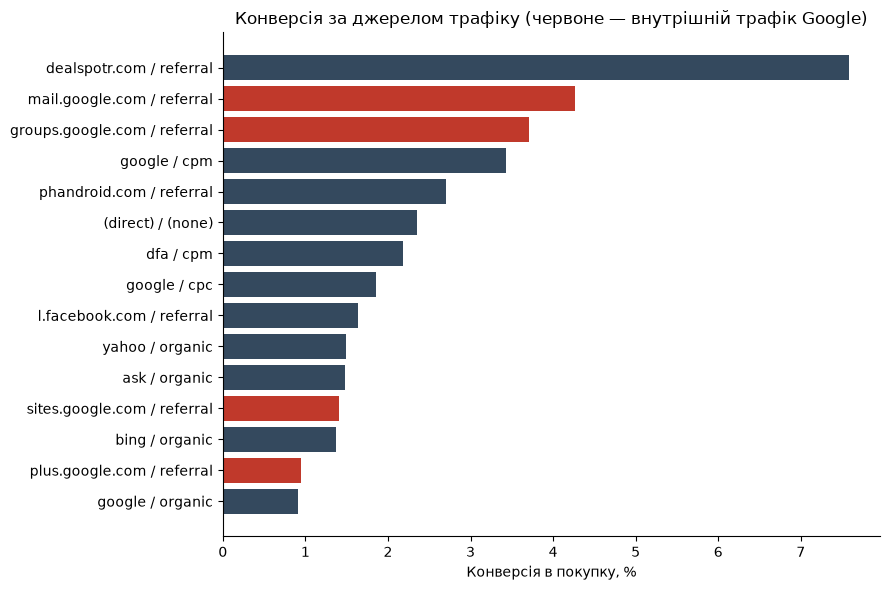

In [39]:
top = ss.head(15).sort_values('conversion_pct')
# єдине джерело правди для списку — використовується і нижче, і в підсумку
INTERNAL_GOOGLE = [
    'mail.google.com', 'groups.google.com', 'sites.google.com',
    'plus.google.com', 'docs.google.com',
]
internal = INTERNAL_GOOGLE
colors = ['#c0392b' if s in internal else '#34495e' for s in top.source]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.source + ' / ' + top.medium, top.conversion_pct, color=colors)
ax.set_xlabel('Конверсія в покупку, %')
ax.set_title('Конверсія за джерелом трафіку (червоне — внутрішній трафік Google)')
plt.tight_layout()
plt.show()

In [40]:
int_rows = ss[ss.source.isin(internal)]
display(int_rows)

print(f'Внутрішній трафік: {int_rows.sessions.sum():,} сесій '
      f'({100 * int_rows.sessions.sum() / sessions:.2f}% усіх)')
print(f'Покупок у ньому:   {int_rows.purchase_sessions.sum():,}')
print()

yt = ss[ss.source == 'youtube.com']
if len(yt):
    print(f'youtube.com: {int(yt.sessions.iloc[0]):,} сесій '
          f'({100 * int(yt.sessions.iloc[0]) / sessions:.1f}% усього трафіку), '
          f'{int(yt.purchase_sessions.iloc[0])} покупок, '
          f'конверсія {yt.conversion_pct.iloc[0]}%')
else:
    print('youtube.com не потрапив у зріз 07_suspicious_sources.csv')

,source,medium,sessions,purchase_sessions,conversion_pct
1,mail.google.com,referral,1457,62,4.26
2,groups.google.com,referral,1025,38,3.71
11,sites.google.com,referral,2983,42,1.41
13,plus.google.com,referral,524,5,0.95
20,docs.google.com,referral,388,1,0.26


Внутрішній трафік: 6,377 сесій (0.71% усіх)
Покупок у ньому:   148

youtube.com: 212,602 сесій (23.6% усього трафіку), 11 покупок, конверсія 0.01%


Внутрішній трафік Google справді присутній: `mail.google.com`, `groups.google.com`, `sites.google.com`, `plus.google.com`, `docs.google.com` конвертують у 2–5 разів краще за середнє. Але його обсяг малий — разом 6 377 сесій, 0,7% від усіх. Виключаю ці п'ять джерел з міжканальних порівнянь, а конверсію групи Referral показую у двох варіантах, з ними і без них.

Найвища конверсія в списку взагалі в іншого джерела — `dealspotr.com`, 7,58%. Це купонний агрегатор, і висока конверсія там очікувана: люди приходять з готовим наміром купити зі знижкою. Залишаю. Підставою для виключення є нерепрезентативність аудиторії, а не саме по собі високе число. Співробітники, які заходять із внутрішньої пошти, — це не покупці магазину мерчу в тому ж сенсі, що зовнішні відвідувачі, тож їхня конверсія не є властивістю каналу Referral. Купонний сайт — звичайний зовнішній канал, і його виключення було б підгонкою даних під очікування.

І окремо — знахідка, якої я не шукала: `youtube.com` дає 212 602 сесії, майже чверть усього трафіку, і 11 покупок. Конверсія 0,01%. Залишаю обов'язково.

Мінімальний розмір комірки — 100 сесій. Цей поріг уже стоїть у запиті `07_suspicious_sources.sql`, і після перегляду даних я його підтверджую: на рівні каналів він ні на що не впливає, бо в `channelGrouping` вісім груп і найменша з них на порядки більша. Діяти він почне на дрібних розрізах — канал × пристрій × крок воронки — і саме там потрібен.

## Рішення за підсумками перевірки

| # | Рішення | Впливає на гіпотези |
|---|---|---|
| 1 | Виключені джерела: `mail.google.com`, `groups.google.com`, `sites.google.com`, `plus.google.com`, `docs.google.com` | 1, 3, 4 |
| 2 | Мінімальний розмір комірки — 100 сесій | 1, 2 |
| 3 | Ключ сесії — `fullVisitorId + visitId + date` | усі |
| 4 | Воронка монотонна; строга версія рахується як контроль | **1, 2** |
| 5 | Джерело правди для виручки — рівень сесії | 3 |
| 6 | `NULL` у виручці не замінюється нулем; середній чек — тільки по сесіях з покупкою | 3 |
| 7 | Транзакції рахуються як `COUNT(DISTINCT transactionId)`, ніколи не сумуванням по хітах | 3 |
| 8 | `direct`, `youtube.com`, `dealspotr.com` залишаються в аналізі | 1, 4 |

У `hypotheses.md` переносяться рішення №1, 2, 4, 5 і 6 — ті, що впливають на перевірку гіпотез. Решта стосується техніки виконання й лишається тут.

Рішення №4 — єдине, що змінює сам результат перевірки. Тому воно фіксується до першого тесту.

## Що перевірка даних уже сказала про гіпотези

Три речі, які варто прочитати до аналізу. Жодна не є результатом перевірки й жодна не змінює формулювань.

**Ставки у гіпотезі 4 вищі, ніж я думала.** Direct — 41% трафіку, тобто найбільший бенефіціар атрибуції за останнім кліком — це найбільша група в датасеті, а не маргінальний канал. Водночас сесій на відвідувача лише 1,27: більшість людей приходить один раз, і для них first-touch збігається з last-click. Ці два факти тягнуть у різні боки, і наперед незрозуміло, який переважить.

**У гіпотезі 1 з'явився конкурент серед пояснень.** `youtube.com` — чверть трафіку з конверсією 0,01%. Якщо розкид між каналами вгорі воронки виявиться великим, перша підозра має падати на склад груп: можливо, одна з них складається переважно з відео-трафіку, який ніколи не збирався нічого купувати. Тому перед тестуванням гіпотези 1 треба подивитися склад груп `channelGrouping` за джерелами — інакше висновок буде про youtube, а не про канали.

**Гіпотеза 3 методично підтверджена.** Розподіл чеків скошений настільки, що між p99 і максимумом ще у 18 разів. Відмова від t-тесту на користь коефіцієнтів варіації була правильною.

